# 🗂️ **Skripsi** : ANALISIS SENTIMEN — INDOBERT FINE-TUNING (STANDALONE)

**Author**   : [Nofendra Tahta Dirgantara]

**Pipeline** : Load → Clean → Preprocess → Label → Tokenize → Fine-Tune IndoBERT → Evaluasi → Bandingkan dengan RF → Save → Infer

---

### 💡 **Deskripsi Notebook**
Notebook ini adalah **pendamping** dari `LPDP_RF_OPTIMIZED.ipynb`. Tujuannya adalah membangun model klasifikasi sentimen kedua menggunakan **IndoBERT** (`indobenchmark/indobert-base-p1`), sebuah model *transformer* berbasis BERT yang telah dilatih khusus pada korpus Bahasa Indonesia, untuk dibandingkan performanya terhadap model **Random Forest + TF-IDF** yang sudah dibangun sebelumnya.

Agar perbandingan adil (*apple-to-apple*), notebook ini:
- Memuat **dataset yang sama** dari sumber yang sama.
- Menjalankan **proses cleaning & pelabelan lexicon yang identik** (kelas `TextPreprocessor` dan `LexiconLabeler` direplikasi persis dari notebook RF), sehingga **distribusi label (`Positif` / `Netral` / `Negatif`) yang dihasilkan akan sama**.
- Menggunakan **train-test split dengan `random_state` yang sama** (stratified 80/20).

**Perbedaan penting**: untuk input ke IndoBERT, teks **tidak** melalui tahap *stemming* dan *stopword removal* seperti pada pipeline TF-IDF. Hal ini disengaja — model BERT berbasis *subword tokenizer* dan *self-attention*, sehingga justru bekerja lebih baik dengan kalimat yang **utuh secara struktur** (termasuk imbuhan dan kata tugas), bukan teks yang sudah "dipotong-potong". Label tetap diturunkan dari `processed_text` (hasil lexicon-based labeling) agar konsisten dengan notebook RF.

⚠️ **Catatan menjalankan**: Notebook ini **wajib** dijalankan di Google Colab dengan **GPU runtime** diaktifkan (`Runtime > Change runtime type > T4 GPU`), karena fine-tuning transformer jauh lebih berat dibanding Random Forest dan akan sangat lambat di CPU.


# ⚙️ INSTALASI DEPENDENCY

In [ ]:
# ── INSTALL DEPENDENCY (Untuk Google Colab jika diperlukan) ────
!pip install transformers datasets accelerate sastrawi joblib scikit-learn seaborn matplotlib evaluate -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.7 MB/s eta 0:00:00


# 📦 IMPORT LIBRARY & GLOBAL CONFIGURATION

In [ ]:
import re
import os
import json
import warnings
import joblib
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO
from datetime import datetime

import torch
from torch.utils.data import Dataset

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    DataCollatorWithPadding,
)

# Konfigurasi Global
warnings.filterwarnings("ignore")
pd.options.mode.chained_assignment = None
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Nama model pretrained IndoBERT (IndoBenchmark, Wilie et al.)
MODEL_NAME = "indobenchmark/indobert-base-p1"

# Warna konsisten untuk 3 kelas sentimen (sama seperti notebook RF)
SENTIMENT_COLORS = {
    "Positif": "#2ecc71",
    "Netral":  "#3498db",
    "Negatif": "#e74c3c",
}

print("✅ Semua library berhasil diimport.")
print(f"🖥️  Device terdeteksi : {DEVICE}")
if DEVICE == "cpu":
    print("⚠️  PERINGATAN: GPU tidak terdeteksi! Fine-tuning IndoBERT di CPU akan SANGAT lambat.")
    print("    Aktifkan GPU di Colab: Runtime > Change runtime type > T4 GPU")


✅ Semua library berhasil diimport.
🖥️  Device terdeteksi : cuda


# 📥 LOAD DATASET

In [ ]:
DATASET_URL = (
    "https://raw.githubusercontent.com/go0se05/Analysis-Sentiment_LPDP/refs/heads/main/master_data_LPDP.csv"
)
COLS_TO_USE = ["id_str", "created_at", "full_text", "lang"]

print("📥 Memuat dataset dari GitHub ...")
df = pd.read_csv(DATASET_URL, low_memory=False)

# Pastikan kolom yang dibutuhkan tersedia dan ambil yang relevan
df = df[COLS_TO_USE].copy()

print(f"\n📊 Informasi Dataset Awal:")
print(f"  Jumlah baris   : {df.shape[0]:,}")
print(f"  Jumlah kolom   : {df.shape[1]}")
print(f"  Kolom          : {list(df.columns)}")
print(f"\n🔍 5 Data Pertama:")
df.head(5)


📥 Memuat dataset dari GitHub ...

📊 Informasi Dataset Awal:
  Jumlah baris   : 5,299
  Jumlah kolom   : 4
  Kolom          : ['id_str', 'created_at', 'full_text', 'lang']

🔍 5 Data Pertama:


,id_str,created_at,full_text,lang
0,2043718234973860099,Mon Apr 13 15:49:32 +0000 2026,@dearkangbra gak memegang prinsip cukup aku aj...,in
1,2043291003906654504,Sun Apr 12 11:31:52 +0000 2026,@Soyasoy18190804 @GunakanOtakKau @MeeRebus11 I...,in
2,2043259169130881509,Sun Apr 12 09:25:22 +0000 2026,@Gooren26 @GunakanOtakKau @MeeRebus11 Anti Mal...,in
3,2042531874871075166,Fri Apr 10 09:15:22 +0000 2026,@semesta_han @Kimmywithyou Sabar cukup aku aja...,in
4,2040226887407136770,Sat Apr 04 00:36:10 +0000 2026,@WatchmenID Cukup aku aja yang WNI anakku jangan,in


# 🧼 DATA CLEANING

### Hapus Missing Values & Duplikat

In [ ]:
print("=" * 55)
print("📋 STATUS AWAL DATA")
print("=" * 55)
print(f"  Total baris            : {len(df):,}")
print(f"  Duplikat (full_text)   : {df.duplicated(subset=['full_text']).sum():,}")
print(f"  Missing (full_text)    : {df['full_text'].isna().sum():,}")

before = len(df)

# Langkah 1 — Hapus baris dengan missing value di kolom full_text
df = df.dropna(subset=["full_text"]).copy()
after_na = len(df)

# Langkah 2 — Hapus duplikat berdasarkan full_text
df = df.drop_duplicates(subset=["full_text"]).reset_index(drop=True)
after_dup = len(df)

print("\n" + "=" * 55)
print("📋 STATUS SETELAH CLEANING")
print("=" * 55)
print(f"  Baris awal              : {before:,}")
print(f"  Setelah hapus NA         : {after_na:,} (Dihapus: {before - after_na:,})")
print(f"  Setelah hapus duplikat   : {after_dup:,} (Dihapus: {after_na - after_dup:,})")


📋 STATUS AWAL DATA
  Total baris            : 5,299
  Duplikat (full_text)   : 167
  Missing (full_text)    : 0

📋 STATUS SETELAH CLEANING
  Baris awal              : 5,299
  Setelah hapus NA         : 5,299 (Dihapus: 0)
  Setelah hapus duplikat   : 5,132 (Dihapus: 167)


# ⚙️ PREPROCESSING (REUSE LOGIC DARI NOTEBOOK RANDOM FOREST)

Untuk menjaga **konsistensi label** antar kedua model, kelas `TextPreprocessor` dan `LexiconLabeler` di bawah ini **direplikasi persis** dari `LPDP_RF_OPTIMIZED.ipynb`. Hasil `processed_text` (sudah distem & dibuang stopword) tetap digunakan **khusus untuk proses pelabelan lexicon**, bukan sebagai input ke IndoBERT.

### Performance Monkey-Patch untuk Sastrawi ArrayDictionary

In [ ]:
from Sastrawi.Dictionary.ArrayDictionary import ArrayDictionary

def _patched_init(self, words=None):
    self.words = set()
    if words:
        self.add_words(words)

def _patched_contains(self, word):
    if not word or word.strip() == '':
        return False
    return word in self.words

def _patched_count(self):
    return len(self.words)

def _patched_add_words(self, words):
    clean_words = {w for w in words if w and w.strip() != ''}
    self.words.update(clean_words)

def _patched_add(self, word):
    if not word or word.strip() == '':
        return
    self.words.add(word)

ArrayDictionary.__init__ = _patched_init
ArrayDictionary.contains = _patched_contains
ArrayDictionary.count = _patched_count
ArrayDictionary.add_words = _patched_add_words
ArrayDictionary.add = _patched_add

print("⚡ Sastrawi ArrayDictionary berhasil dipatch dengan Set (pencarian O(1))!")


⚡ Sastrawi ArrayDictionary berhasil dipatch dengan Set (pencarian O(1))!


### Definisi Kelas `TextPreprocessor` (Identik dengan Notebook RF)

In [ ]:
# Kata-kata bahasa Indonesia yang dominan untuk deteksi bahasa secara cepat (heuristic)
STRONG_ID_WORDS = {
    "yg", "dgn", "nya", "jg", "juga", "ini", "itu", "dan", "atau", "untuk",
    "dengan", "ada", "tidak", "bisa", "aja", "gak", "ga", "gw", "aku",
    "kamu", "saya", "kalian", "kita", "mereka", "dia", "udah", "sudah",
    "jadi", "sih", "deh", "nih", "lah", "dong", "banget", "bgt"
}

# Kamus normalisasi kata alay/singkatan offline (fallback)
DEFAULT_KAMUS_BAKU = {
    "gak": "tidak", "ga": "tidak", "udah": "sudah",
    "gimana": "bagaimana", "kalo": "kalau", "aja": "saja",
    "bgt": "banget", "yg": "yang", "dgn": "dengan",
    "tdk": "tidak", "blm": "belum", "sdh": "sudah",
    "krn": "karena", "utk": "untuk", "lg": "lagi",
    "emg": "memang", "ttp": "tetap", "hrs": "harus",
    "pake": "pakai", "pengen": "ingin", "kmrn": "kemarin",
    "abis": "habis", "bikin": "membuat", "nggak": "tidak",
}

# Stopwords kustom khusus konteks Twitter/Sosmed Indonesia
CUSTOM_STOPWORDS = {
    "yg", "dgn", "nya", "jg", "juga", "ini", "itu", "dan", "atau", "untuk",
    "dengan", "ada", "tidak", "bisa", "aja", "gak", "ga", "gw", "aku",
    "kamu", "saya", "kalian", "kita", "mereka", "dia", "udah", "sudah",
    "jadi", "ya", "sih", "deh", "nih", "lah", "dong", "banget", "bgt",
    "wkwk", "haha", "lol", "wah", "oh", "ah", "eh", "hm",
    "rt", "amp", "via", "cc", "https", "http", "co", "www",
}

class TextPreprocessor:
    def __init__(self, kamus_url="https://raw.githubusercontent.com/go0se05/PI/main/kamuskatabaku.csv"):
        # Inisialisasi stemmer Sastrawi
        stemmer_factory = StemmerFactory()
        self.stemmer = stemmer_factory.create_stemmer()

        # Inisialisasi Stopwords
        sw_factory = StopWordRemoverFactory()
        self.stopwords_set = set(sw_factory.get_stop_words())
        self.stopwords_set.update(CUSTOM_STOPWORDS)

        # Muat Kamus Normalisasi
        self.kamus_baku = self._load_normalization_dict(kamus_url)

        # Precompile pola regex untuk optimasi performa
        self.url_pattern = re.compile(r"http\S+|www\S+")
        self.mention_pattern = re.compile(r"@\w+")
        self.hashtag_pattern = re.compile(r"#(\w+)")
        self.emoji_pattern = re.compile(
            "["
            "\U0001F600-\U0001F64F"
            "\U0001F300-\U0001F5FF"
            "\U0001F680-\U0001F6FF"
            "\U0001F700-\U0001F77F"
            "\U0001F780-\U0001F7FF"
            "\U0001F800-\U0001F8FF"
            "\U0001F900-\U0001F9FF"
            "\U0001FA00-\U0001FA6F"
            "\U0001FA70-\U0001FAFF"
            "\U00002702-\U000027B0"
            "]+",
            flags=re.UNICODE,
        )
        self.digits_pattern = re.compile(r"\d+")
        self.non_alpha_pattern = re.compile(r"[^\w\s]")
        self.underscores_pattern = re.compile(r"_+")
        self.spaces_pattern = re.compile(r"\s+")

    def _load_normalization_dict(self, url):
        try:
            r = requests.get(url, timeout=10)
            r.raise_for_status()
            df_k = pd.read_csv(StringIO(r.text))
            cols = df_k.columns.str.lower().tolist()
            if "tidak_baku" in cols and "kata_baku" in cols:
                mapping = dict(zip(df_k["tidak_baku"], df_k["kata_baku"]))
            else:
                mapping = dict(zip(df_k.iloc[:, 0], df_k.iloc[:, 1]))
            return mapping
        except Exception as e:
            print(f"⚠️ Gagal memuat kamus kata baku dari URL ({e}). Menggunakan kamus fallback.")
            return DEFAULT_KAMUS_BAKU

    def filter_text(self, text):
        if not isinstance(text, str):
            return ""
        text = self.url_pattern.sub(" ", text)
        text = self.mention_pattern.sub(" ", text)
        text = self.hashtag_pattern.sub(r"\1", text)
        text = self.emoji_pattern.sub(" ", text)
        text = self.digits_pattern.sub(" ", text)
        text = self.non_alpha_pattern.sub(" ", text)
        text = self.underscores_pattern.sub(" ", text)
        text = self.spaces_pattern.sub(" ", text).strip()
        return text

    def is_indonesian(self, text):
        words = text.split()
        if len(words) < 3:
            return True
        id_words_count = sum(1 for w in words if w in STRONG_ID_WORDS)
        if id_words_count >= 2:
            return True
        try:
            from langdetect import detect, LangDetectException
            return detect(text) == "id"
        except Exception:
            return True

    def normalize_words(self, text):
        words = text.split()
        normalized = [self.kamus_baku.get(w, w) for w in words]
        return " ".join(normalized)

    def remove_stopwords(self, text):
        words = text.split()
        filtered = [w for w in words if w not in self.stopwords_set and len(w) > 1]
        return " ".join(filtered)

    def stem(self, text):
        if not text.strip():
            return ""
        return self.stemmer.stem(text)

    def preprocess(self, text, filter_lang=True):
        # Pipeline LENGKAP (filter -> lower -> normalize -> stopword -> stem).
        # Dipakai untuk menghasilkan `processed_text` yang menjadi basis pelabelan lexicon,
        # SAMA seperti pada notebook Random Forest.
        text_clean = self.filter_text(text)
        if not text_clean:
            return ""
        text_lower = text_clean.lower()
        if filter_lang and not self.is_indonesian(text_lower):
            return ""
        text_norm = self.normalize_words(text_lower)
        text_sw = self.remove_stopwords(text_norm)
        text_stem = self.stem(text_sw)
        return text_stem

    def preprocess_for_bert(self, text, filter_lang=True):
        # Pipeline RINGAN (filter -> lower -> normalize) TANPA stopword removal & stemming.
        # Mempertahankan struktur kalimat & kata tugas (termasuk negasi seperti 'tidak', 'jangan')
        # karena IndoBERT memanfaatkan konteks urutan kata melalui self-attention.
        text_clean = self.filter_text(text)
        if not text_clean:
            return ""
        text_lower = text_clean.lower()
        if filter_lang and not self.is_indonesian(text_lower):
            return ""
        text_norm = self.normalize_words(text_lower)
        return text_norm.strip()

print("✅ Kelas TextPreprocessor siap (dengan tambahan method `preprocess_for_bert`).")


✅ Kelas TextPreprocessor siap (dengan tambahan method `preprocess_for_bert`).


In [ ]:
print("⚙️ Menginisialisasi TextPreprocessor ...")
preprocessor = TextPreprocessor()

print("\n🚀 Menjalankan pipeline preprocessing LENGKAP pada kolom full_text (untuk basis pelabelan)...")
df["processed_text"] = df["full_text"].apply(preprocessor.preprocess)

print("🚀 Menjalankan pipeline preprocessing RINGAN pada kolom full_text (untuk input IndoBERT)...")
df["text_for_bert"] = df["full_text"].apply(preprocessor.preprocess_for_bert)

# Menghapus baris yang kosong di SALAH SATU versi teks setelah preprocessing
before_empty_filter = len(df)
df = df[
    (df["processed_text"].str.strip().str.len() > 0) &
    (df["text_for_bert"].str.strip().str.len() > 0)
].reset_index(drop=True)
after_empty_filter = len(df)

print(f"\n✅ Preprocessing selesai!")
print(f"  Baris sebelum filter kosong: {before_empty_filter:,}")
print(f"  Baris setelah filter kosong: {after_empty_filter:,} (Dihapus: {before_empty_filter - after_empty_filter:,})")
print(f"\n🔍 Contoh perbandingan hasil preprocessing:")
df[["full_text", "processed_text", "text_for_bert"]].head(5)


⚙️ Menginisialisasi TextPreprocessor ...

🚀 Menjalankan pipeline preprocessing LENGKAP pada kolom full_text (untuk basis pelabelan)...
🚀 Menjalankan pipeline preprocessing RINGAN pada kolom full_text (untuk input IndoBERT)...

✅ Preprocessing selesai!
  Baris sebelum filter kosong: 5,132
  Baris setelah filter kosong: 5,132 (Dihapus: 0)

🔍 Contoh perbandingan hasil preprocessing:


,full_text,processed_text,text_for_bert
0,@dearkangbra gak memegang prinsip cukup aku aj...,pegang prinsip cukup warga negara indonesia an...,tidak memegang prinsip cukup aku saja yang war...
1,@Soyasoy18190804 @GunakanOtakKau @MeeRebus11 I...,indonesia butuh manusia biar warga negara indo...,indonesia tidak butuh manusia biar aku saja wa...
2,@Gooren26 @GunakanOtakKau @MeeRebus11 Anti Mal...,anti malaysia wujud istilah jasad indonesia pe...,anti malaysia tapi wujud istilah jasad di indo...
3,@semesta_han @Kimmywithyou Sabar cukup aku aja...,sabar cukup warga negara indonesia anak jangan,sabar cukup aku saja yang warga negara indones...
4,@WatchmenID Cukup aku aja yang WNI anakku jangan,cukup warga negara indonesia anak jangan,cukup aku saja yang warga negara indonesia ana...


# 🏷️ PELABELAN (LEXICON-BASED SENTIMENT LABELING — IDENTIK DENGAN NOTEBOOK RF)

Kelas `LexiconLabeler` ini **direplikasi persis** dari notebook Random Forest, termasuk kamus **InSet (Fajri et al.)** dan override domain-spesifik (kata seperti *lpdp*, *beasiswa*, *seleksi*, kata negasi, kata waktu, dll. dinetralkan agar tidak bias). Tujuannya supaya `label` yang dihasilkan **identik** dengan yang dipakai model RF, sehingga IndoBERT dilatih & dievaluasi pada **ground truth yang sama persis**.

In [ ]:
DEFAULT_POS_LEXICON = {
    "bagus": 3, "senang": 4, "hebat": 4, "cinta": 5, "setuju": 3, "baik": 3,
    "lolos": 4, "sukses": 4, "semangat": 4, "terima kasih": 5, "membantu": 3,
    "bangga": 4, "alhamdulillah": 5, "untung": 3, "mudah": 3, "menang": 4,
}

DEFAULT_NEG_LEXICON = {
    "jelek": -3, "marah": -4, "benci": -5, "kecewa": -4, "gagal": -4,
    "susah": -3, "ribet": -3, "buruk": -3, "rugi": -3, "lemah": -2,
    "mahal": -2, "salah": -2, "mengecewakan": -5, "amburadul": -4,
}

class LexiconLabeler:
    def __init__(
        self,
        pos_url="https://raw.githubusercontent.com/fajri91/InSet/master/positive.tsv",
        neg_url="https://raw.githubusercontent.com/fajri91/InSet/master/negative.tsv"
    ):
        self.lexicon_pos = self._load_tsv_lexicon(pos_url, is_positive=True)
        self.lexicon_neg = self._load_tsv_lexicon(neg_url, is_positive=False)
        self._resolve_conflicts()
        self._apply_overrides()

    def _load_tsv_lexicon(self, url, is_positive):
        try:
            r = requests.get(url, timeout=10)
            r.raise_for_status()
            df_l = pd.read_csv(StringIO(r.text), sep="\t", header=None, names=["word", "weight"])
            df_l["word"] = df_l["word"].astype(str).str.lower().str.strip()
            df_l["weight"] = pd.to_numeric(df_l["weight"], errors="coerce")
            df_l = df_l.dropna(subset=["weight"])
            df_l["weight"] = df_l["weight"].astype(int)
            return dict(zip(df_l["word"], df_l["weight"]))
        except Exception as e:
            print(f"⚠️ Gagal memuat leksikon dari URL ({e}). Menggunakan fallback lokal.")
            return DEFAULT_POS_LEXICON if is_positive else DEFAULT_NEG_LEXICON

    def _resolve_conflicts(self):
        conflicts = set(self.lexicon_pos.keys()) & set(self.lexicon_neg.keys())
        for word in conflicts:
            pos_val = self.lexicon_pos[word]
            neg_val = abs(self.lexicon_neg[word])
            if pos_val > neg_val:
                self.lexicon_pos[word] = pos_val - neg_val
                self.lexicon_neg.pop(word, None)
            elif neg_val > pos_val:
                self.lexicon_neg[word] = -(neg_val - pos_val)
                self.lexicon_pos.pop(word, None)
            else:
                self.lexicon_pos.pop(word, None)
                self.lexicon_neg.pop(word, None)

    def _apply_overrides(self):
        # Kustomisasi bobot leksikon untuk mengurangi bias sentimen dan noise
        lexicon_overrides = {
            "lolos": 4, "bantu": 4, "membantu": 4, "benar": 2, "bangga": 4, "alhamdulillah": 5,
            "bagus": 4, "sukses": 4, "hebat": 4, "cinta": 5, "setuju": 3, "baik": 3,
            "semangat": 4, "terimakasih": 5, "untung": 3, "mudah": 3, "menang": 4,
            "bahagia": 4, "cocok": 3, "kuat": 3, "luar biasa": 4, "senang": 4,
            "gembira": 4, "puji": 3, "bersyukur": 5, "aman": 3, "damai": 3, "maju": 3,
            "pintar": 3, "cerdas": 4, "kreatif": 3,
            "kecewa": -4, "mengecewakan": -5, "ribet": -3, "buruk": -4, "jelek": -3,
            "gagal": -4, "susah": -3, "sulit": -3, "rugi": -3, "lemah": -2, "mahal": -2,
            "salah": -2, "benci": -5, "marah": -4, "amburadul": -4, "parah": -3,
            "payah": -3, "hancur": -4, "kacau": -4, "masalah": -3, "permasalahan": -3, "mending": 2, "penting": 1, "layak": 2, "wajar": 1,
            "tuntut": -2, "tuntutan": -2, "sesal": -3, "menyesal": -3,
            "cukup": 0, "anak": 0, "jangan": 0, "tidak": 0, "gak": 0, "ga": 0, "nggak": 0, "harus": 0, "sistem": 0, "tau": 0, "tahu": 0, "dari": 0, "data": 0,
            "itu": 0, "sendiri": 0, "bukan": 0, "soal": 0, "lain": 0, "dunia": 0, "walau": 0, "sekadar": 0, "nyari": 0, "cari": 0, "ngerasa": 0, "rasa": 0, "merasa": 0, "mikir": 0, "pikir": 0, "lagi": 0, "hidup": 0, "apa": 0, "semua": 0, "ikut": 0, "kalau": 0, "kalo": 0, "kayak": 0, "pilih": 0,
            "kata": 0, "masuk": 0, "pajak": 0, "sama": 0, "punya": 0, "buat": 0, "bikin": 0,
            "laku": 0, "lakukan": 0, "ada": 0, "adalah": 0, "yaitu": 0, "merupakan": 0,
            "menjadi": 0, "jadi": 0, "bisa": 0, "dapat": 0, "luar": 0, "negeri": 0,
            "dalam": 0, "negara": 0, "indonesia": 0, "warga": 0, "rakyat": 0, "lpdp": 0,
            "beasiswa": 0, "awardee": 0, "penerima": 0, "penerimabeasiswa": 0, "pendaftaran": 0,
            "daftar": 0, "seleksi": 0, "syarat": 0, "reguler": 0, "kuota": 0, "kuliah": 0,
            "sekolah": 0, "studi": 0, "belajar": 0, "pendidikan": 0, "didik": 0, "universitas": 0,
            "kampus": 0, "uras": 0, "brain": 0, "drain": 0, "alumni": 0, "lulusan": 0,
            "video": 0, "unggah": 0, "posting": 0, "cuitan": 0, "tweet": 0, "netizen": 0,
            "warganet": 0, "bapak": 0, "ibu": 0, "orang": 0, "orangtua": 0, "keluarga": 0,
            "tahun": 0, "bulan": 0, "hari": 0, "jam": 0, "tanggal": 0, "juni": 0, "juli": 0,
            "waktu": 0, "kali": 0, "dulu": 0, "sekarang": 0, "nanti": 0, "besok": 0,
            "kemarin": 0, "lusa": 0, "info": 0, "bilang": 0, "lanjut": 0, "akhir": 0, "batas": 0,
            "sedia": 0, "lengkap": 0, "resmi": 0, "buka": 0, "banyak": 0, "proses": 0, "sangat": 0,
            "sering": 0, "pemberitahuan": 0, "jelas": 0, "dokumen": 0, "admin": 0, "adminnya": 0,
            "ubah": 0, "berubah": 0, "pelamar": 0, "lamar": 0, "birokrasi": 0
        }
        for word, weight in lexicon_overrides.items():
            if weight > 0:
                self.lexicon_pos[word] = weight
                self.lexicon_neg.pop(word, None)
            elif weight < 0:
                self.lexicon_neg[word] = weight
                self.lexicon_pos.pop(word, None)
            else:
                self.lexicon_pos.pop(word, None)
                self.lexicon_neg.pop(word, None)

    def label_sentiment(self, text):
        if not isinstance(text, str) or not text.strip():
            return 0, "Netral"
        score = 0
        words = text.split()
        for token in words:
            score += self.lexicon_pos.get(token, 0)
            score -= abs(self.lexicon_neg.get(token, 0))
        if score > 0:
            return score, "Positif"
        elif score < 0:
            return score, "Negatif"
        else:
            return 0, "Netral"

print("✅ Kelas LexiconLabeler siap (identik dengan notebook RF).")


✅ Kelas LexiconLabeler siap (identik dengan notebook RF).


In [ ]:
print("🏷️ Menginisialisasi LexiconLabeler ...")
labeler = LexiconLabeler()

print("\n⏳ Menghitung skor sentimen dan menetapkan label kelas (berbasis `processed_text`) ...")
lexicon_results = [labeler.label_sentiment(t) for t in df["processed_text"]]
df["Score"] = [r[0] for r in lexicon_results]
df["label"] = [r[1] for r in lexicon_results]

print("\n✅ Pelabelan selesai!")
dist = df["label"].value_counts()
print("📊 Distribusi Kelas Sentimen Hasil Pelabelan Leksikon (harus identik dengan notebook RF):")
for kls, jml in dist.items():
    pct = (jml / len(df)) * 100
    print(f"  - {kls:<8}: {jml:>6,} ({pct:>5.1f}%)")


🏷️ Menginisialisasi LexiconLabeler ...

⏳ Menghitung skor sentimen dan menetapkan label kelas (berbasis `processed_text`) ...

✅ Pelabelan selesai!
📊 Distribusi Kelas Sentimen Hasil Pelabelan Leksikon (harus identik dengan notebook RF):
  - Positif :  2,431 ( 47.4%)
  - Negatif :  2,351 ( 45.8%)
  - Netral  :    350 (  6.8%)


# 📊 VERIFIKASI DISTRIBUSI KELAS

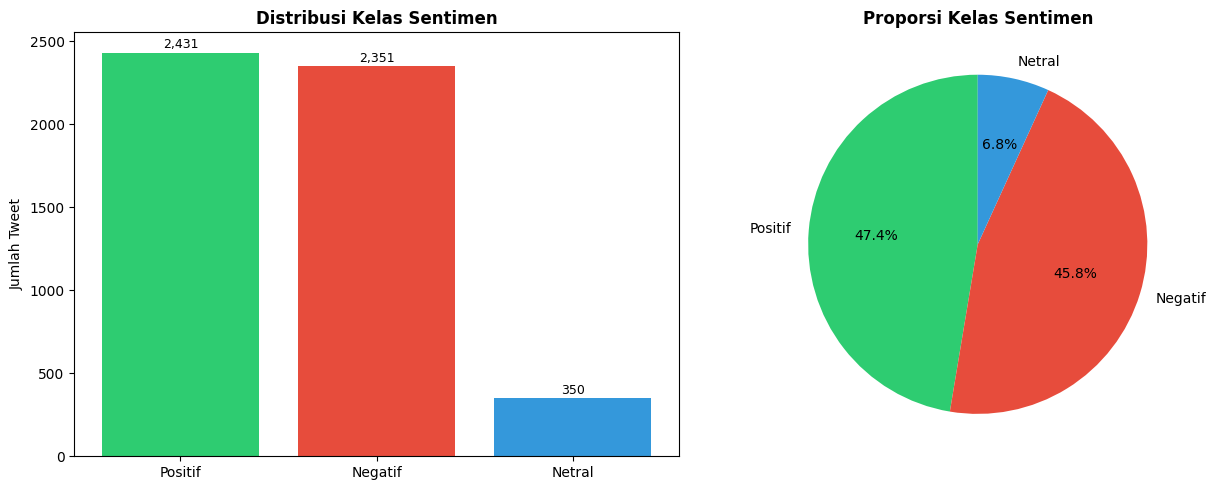

In [ ]:
dist = df["label"].value_counts()
labels_order = dist.index.tolist()
counts = dist.values.tolist()
colors = [SENTIMENT_COLORS.get(l, "#95a5a6") for l in labels_order]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(labels_order, counts, color=colors)
axes[0].set_title("Distribusi Kelas Sentimen", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Jumlah Tweet")
for i, v in enumerate(counts):
    axes[0].text(i, v + max(counts) * 0.01, f"{v:,}", ha="center", fontsize=9)

axes[1].pie(counts, labels=labels_order, autopct="%1.1f%%", colors=colors, startangle=90)
axes[1].set_title("Proporsi Kelas Sentimen", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()


# 🔧 DATA PREPARATION (TOKENISASI & ENCODING UNTUK BERT)

Berbeda dengan pipeline RF yang menggunakan **TF-IDF**, IndoBERT membutuhkan **tokenizer subword** miliknya sendiri (`AutoTokenizer`) yang akan mengubah teks menjadi `input_ids` dan `attention_mask`. Kita menggunakan kolom `text_for_bert` (teks yang sudah dibersihkan tapi belum distem/dibuang stopword-nya) sebagai input, dan `label` (hasil lexicon labeling) sebagai target — identik dengan target pada notebook RF.

In [ ]:
print("🔧 Menyiapkan data untuk pemodelan IndoBERT ...")

df["text_for_bert"] = df["text_for_bert"].fillna("")
X_text = df["text_for_bert"].tolist()
y_raw = df["label"]

# ── 1. Label Encoding (SAMA seperti notebook RF) ──────────────────
le = LabelEncoder()
y = le.fit_transform(y_raw)
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
id2label = {int(v): k for k, v in label_mapping.items()}
label2id = {k: int(v) for k, v in label_mapping.items()}
num_labels = len(le.classes_)
print(f"  Label Mapping  : {label_mapping}")
print(f"  Jumlah kelas   : {num_labels}")

# ── 2. Train-Test Split (80/20 Stratified, random_state SAMA dengan RF) ──
train_texts, test_texts, y_train, y_test = train_test_split(
    X_text, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)
print(f"  Data Train: {len(train_texts)} | Data Test: {len(test_texts)}")

# ── 3. Load Tokenizer IndoBERT ────────────────────────────────────
print(f"\n📦 Memuat tokenizer dari '{MODEL_NAME}' ...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

MAX_LENGTH = 128  # cukup untuk panjang tweet (maks 280 karakter)

def tokenize_batch(texts):
    return tokenizer(
        texts,
        padding=False,
        truncation=True,
        max_length=MAX_LENGTH,
    )

train_encodings = tokenize_batch(train_texts)
test_encodings = tokenize_batch(test_texts)
print("✅ Tokenisasi selesai!")
print(f"  Contoh token   : {tokenizer.convert_ids_to_tokens(train_encodings['input_ids'][0][:15])}")


🔧 Menyiapkan data untuk pemodelan IndoBERT ...
  Label Mapping  : {'Negatif': np.int64(0), 'Netral': np.int64(1), 'Positif': np.int64(2)}
  Jumlah kelas   : 3
  Data Train: 4105 | Data Test: 1027

📦 Memuat tokenizer dari 'indobenchmark/indobert-base-p1' ...
✅ Tokenisasi selesai!
  Contoh token   : ['[CLS]', 'ini', 'yang', 'membuat', 'gue', 'kesal', 'lihat', 'opini', 'kalau', 'semua', 'orang', 'berpikir', 'begini', 'generasi', 'depan']


### Definisi Kelas `SentimentTorchDataset`

In [ ]:
print(f"🤖 Memuat model '{MODEL_NAME}' untuk fine-tuning klasifikasi sentimen ...")

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
)
model.to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ Model berhasil dimuat!")
print(f"  Total parameter      : {n_params:,}")
print(f"  Parameter trainable   : {n_trainable:,}")


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    f1_macro = f1_score(labels, preds, average="macro")
    f1_weighted = f1_score(labels, preds, average="weighted")
    precision_macro = precision_score(labels, preds, average="macro", zero_division=0)
    recall_macro = recall_score(labels, preds, average="macro", zero_division=0)
    return {
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
    }


🤖 Memuat model 'indobenchmark/indobert-base-p1' untuk fine-tuning klasifikasi sentimen ...


[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `5`.


pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  498MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  498MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model berhasil dimuat!
  Total parameter      : 124,443,651
  Parameter trainable   : 124,443,651


# 🤖 BUILD & FINE-TUNE INDOBERT

### Memuat Model Pretrained & Mendefinisikan Fungsi Metrik
Model `indobenchmark/indobert-base-p1` dimuat dengan *classification head* baru (`AutoModelForSequenceClassification`) yang disesuaikan dengan jumlah kelas (3: Positif/Netral/Negatif). Fungsi `compute_metrics` menghitung akurasi, F1 (macro & weighted), precision, dan recall pada setiap akhir epoch evaluasi — selaras dengan metrik yang dipakai pada notebook RF.

In [ ]:
# ── TAMBAHAN: Hitung Class Weight untuk mengatasi imbalance kelas Netral ──
from sklearn.utils.class_weight import compute_class_weight
import torch.nn as nn

class_weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
class_weights = torch.tensor(class_weights_arr, dtype=torch.float).to(DEVICE)

print("⚖️ Class weights (urutan sesuai label_mapping):")
for cls_name, cls_id in label_mapping.items():
    print(f"  {cls_name:<8}: weight = {class_weights[cls_id]:.4f}")

⚖️ Class weights (urutan sesuai label_mapping):
  Negatif : weight = 0.7274
  Netral  : weight = 4.8869
  Positif : weight = 0.7039


### Setup `TrainingArguments` & Eksekusi Fine-Tuning
Konfigurasi training menggunakan **3 epoch** (umumnya cukup untuk fine-tuning BERT pada dataset berukuran menengah agar tidak overfitting), `learning_rate=2e-5` (nilai standar untuk fine-tuning BERT), serta `load_best_model_at_end=True` berdasarkan `f1_macro` terbaik di data validasi — sehingga model akhir yang dipakai adalah checkpoint terbaik, bukan sekadar epoch terakhir. `EarlyStoppingCallback` ditambahkan sebagai pengaman tambahan terhadap overfitting.

In [ ]:
training_args = TrainingArguments(
    output_dir="bert_checkpoints",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    report_to="none",
    fp16=torch.cuda.is_available(),
    seed=RANDOM_STATE,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print("🚀 Memulai fine-tuning IndoBERT ...")
print("   (Estimasi waktu di GPU T4 Colab: beberapa menit hingga puluhan menit, tergantung ukuran data)\n")
train_result = trainer.train()

print("\n✅ Fine-tuning selesai!")
print(f"  Training loss akhir : {train_result.training_loss:.4f}")


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


🚀 Memulai fine-tuning IndoBERT ...
   (Estimasi waktu di GPU T4 Colab: beberapa menit hingga puluhan menit, tergantung ukuran data)



Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,Precision Macro,Recall Macro
1,0.538036,0.537211,0.783836,0.566189,0.759336,0.781927,0.571840
2,0.336319,0.480582,0.841285,0.721199,0.833071,0.807448,0.691304
3,0.196905,0.513400,0.848101,0.733811,0.842701,0.774018,0.712405


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Fine-tuning selesai!
  Training loss akhir : 0.4143


# 📊 EVALUASI MODEL INDOBERT

⏳ Menjalankan prediksi pada data test ...


IndoBERT Model Accuracy: 84.8101%

📊 Classification Report (IndoBERT):
              precision    recall  f1-score   support

     Negatif       0.86      0.88      0.87       470
      Netral       0.60      0.37      0.46        70
     Positif       0.86      0.89      0.87       487

    accuracy                           0.85      1027
   macro avg       0.77      0.71      0.73      1027
weighted avg       0.84      0.85      0.84      1027



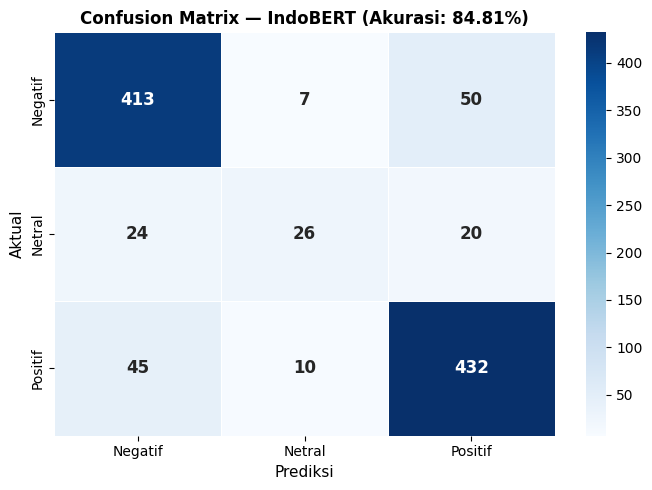

In [ ]:
print("⏳ Menjalankan prediksi pada data test ...")
test_output = trainer.predict(test_dataset)
y_pred_bert = np.argmax(test_output.predictions, axis=-1)
acc_bert = accuracy_score(y_test, y_pred_bert)

print(f"IndoBERT Model Accuracy: {acc_bert:.4%}")
print("\n📊 Classification Report (IndoBERT):")
print(classification_report(y_test, y_pred_bert, target_names=le.classes_))

# Plot Confusion Matrix IndoBERT
cm_bert = confusion_matrix(y_test, y_pred_bert)
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_bert, annot=True, fmt="d", cmap="Blues",
    xticklabels=le.classes_, yticklabels=le.classes_,
    linewidths=0.5, linecolor="white",
    annot_kws={"size": 12, "weight": "bold"},
)
plt.xlabel("Prediksi", fontsize=11)
plt.ylabel("Aktual", fontsize=11)
plt.title(f"Confusion Matrix — IndoBERT (Akurasi: {acc_bert*100:.2f}%)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


### Diagnostik Overfitting (Train vs Test Accuracy)

Sama seperti diagnostik yang dilakukan pada model Random Forest, kita bandingkan akurasi pada data **train** vs **test** untuk mengecek apakah model mengalami overfitting (gap besar = overfitting).

In [ ]:
print("⏳ Menjalankan prediksi pada data TRAIN untuk cek overfitting ...")
train_output = trainer.predict(train_dataset)
y_pred_train_bert = np.argmax(train_output.predictions, axis=-1)
acc_train_bert = accuracy_score(y_train, y_pred_train_bert)

gap = acc_train_bert - acc_bert

print("=" * 55)
print("🔍 DIAGNOSTIK OVERFITTING — INDOBERT")
print("=" * 55)
print(f"  Akurasi Train  : {acc_train_bert:.4%}")
print(f"  Akurasi Test    : {acc_bert:.4%}")
print(f"  Gap (Train-Test): {gap:.4%}")
if gap > 0.10:
    print("  ⚠️  Gap > 10% — indikasi overfitting cukup signifikan.")
elif gap > 0.05:
    print("  ⚠️  Gap 5–10% — overfitting ringan, masih dalam batas wajar untuk fine-tuning BERT.")
else:
    print("  ✅ Gap < 5% — model generalisasi dengan baik.")
print("=" * 55)


⏳ Menjalankan prediksi pada data TRAIN untuk cek overfitting ...


🔍 DIAGNOSTIK OVERFITTING — INDOBERT
  Akurasi Train  : 95.8587%
  Akurasi Test    : 84.8101%
  Gap (Train-Test): 11.0486%
  ⚠️  Gap > 10% — indikasi overfitting cukup signifikan.


### Kurva Training: Loss & F1-Macro per Epoch

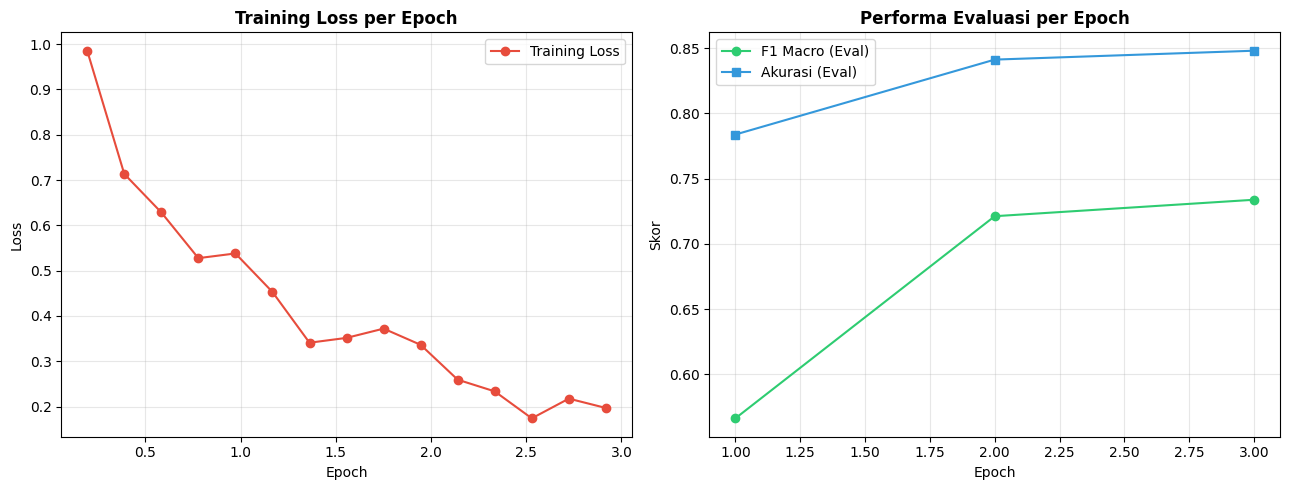

In [ ]:
log_history = trainer.state.log_history

train_steps, train_losses = [], []
eval_epochs, eval_f1, eval_acc = [], [], []

for entry in log_history:
    if "loss" in entry and "epoch" in entry and "eval_loss" not in entry:
        train_steps.append(entry["epoch"])
        train_losses.append(entry["loss"])
    if "eval_f1_macro" in entry:
        eval_epochs.append(entry["epoch"])
        eval_f1.append(entry["eval_f1_macro"])
        eval_acc.append(entry["eval_accuracy"])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(train_steps, train_losses, marker="o", color="#e74c3c", label="Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training Loss per Epoch", fontsize=12, fontweight="bold")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(eval_epochs, eval_f1, marker="o", color="#2ecc71", label="F1 Macro (Eval)")
axes[1].plot(eval_epochs, eval_acc, marker="s", color="#3498db", label="Akurasi (Eval)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Skor")
axes[1].set_title("Performa Evaluasi per Epoch", fontsize=12, fontweight="bold")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ⚖️ PERBANDINGAN RANDOM FOREST vs INDOBERT

Sel berikut membandingkan metrik IndoBERT dengan metrik model **Random Forest (Tuned)** dari notebook sebelumnya. Untuk menjalankan sel ini, isi nilai `acc_tuned`, `f1_macro_tuned`, dst. secara manual dari hasil notebook RF — atau, jika kedua notebook dijalankan dalam satu sesi Colab yang sama (`%run` / `import`), variabel tersebut akan otomatis tersedia.

In [ ]:
# ── Isi manual hasil terbaik dari notebook Random Forest (LPDP_RF_OPTIMIZED.ipynb) ──
# Jika notebook RF sudah dijalankan dalam sesi yang sama, baris ini bisa dihapus
# karena variabel acc_tuned, y_pred_tuned, dll. sudah ada di memori.
try:
    acc_tuned
    rf_available = True
except NameError:
    rf_available = False
    print("ℹ️  Variabel hasil Random Forest tidak ditemukan di sesi ini.")
    print("   Silakan isi manual di bawah berdasarkan hasil notebook LPDP_RF_OPTIMIZED.ipynb,")
    print("   atau jalankan kedua notebook dalam satu sesi Colab yang sama.\n")
    acc_tuned = None          # contoh: 0.8123
    f1_macro_rf = None        # contoh: 0.7894
    f1_weighted_rf = None     # contoh: 0.8056
    precision_macro_rf = None # contoh: 0.7912
    recall_macro_rf = None    # contoh: 0.7833
else:
    f1_macro_rf = f1_score(y_test_rf, y_pred_tuned, average="macro") if "y_test_rf" in dir() else None

metrics_bert = {
    "Model": "IndoBERT (Fine-tuned)",
    "Akurasi": f"{acc_bert:.4f}",
    "F1 Macro": f"{f1_score(y_test, y_pred_bert, average='macro'):.4f}",
    "F1 Weighted": f"{f1_score(y_test, y_pred_bert, average='weighted'):.4f}",
    "Precision Macro": f"{precision_score(y_test, y_pred_bert, average='macro'):.4f}",
    "Recall Macro": f"{recall_score(y_test, y_pred_bert, average='macro'):.4f}",
}

rows = [metrics_bert]
if rf_available and acc_tuned is not None:
    metrics_rf_row = {
        "Model": "Random Forest (Tuned)",
        "Akurasi": f"{acc_tuned:.4f}",
        "F1 Macro": f"{f1_macro_rf:.4f}" if f1_macro_rf is not None else "N/A",
        "F1 Weighted": f"{f1_weighted_rf:.4f}" if f1_weighted_rf else "N/A",
        "Precision Macro": f"{precision_macro_rf:.4f}" if precision_macro_rf else "N/A",
        "Recall Macro": f"{recall_macro_rf:.4f}" if recall_macro_rf else "N/A",
    }
    rows.insert(0, metrics_rf_row)

df_compare_final = pd.DataFrame(rows)
print("=" * 65)
print("PERBANDINGAN METRIK EVALUASI — RANDOM FOREST vs INDOBERT")
print("=" * 65)
print(df_compare_final.to_string(index=False))
print("=" * 65)

if len(rows) == 2:
    fig, ax = plt.subplots(figsize=(9, 5.5))
    metric_names = ["Akurasi", "F1 Macro", "F1 Weighted", "Precision Macro", "Recall Macro"]
    x = np.arange(len(metric_names))
    width = 0.35

    rf_vals = [float(rows[0][m]) for m in metric_names]
    bert_vals = [float(rows[1][m]) for m in metric_names]

    ax.bar(x - width/2, rf_vals, width, label="Random Forest (Tuned)", color="#27ae60")
    ax.bar(x + width/2, bert_vals, width, label="IndoBERT (Fine-tuned)", color="#2980b9")
    ax.set_xticks(x)
    ax.set_xticklabels(metric_names, rotation=15)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Skor")
    ax.set_title("Perbandingan Performa: Random Forest vs IndoBERT", fontsize=12, fontweight="bold")
    ax.legend()
    for i, v in enumerate(rf_vals):
        ax.text(i - width/2, v + 0.01, f"{v:.3f}", ha="center", fontsize=8)
    for i, v in enumerate(bert_vals):
        ax.text(i + width/2, v + 0.01, f"{v:.3f}", ha="center", fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print("\nℹ️  Grafik perbandingan dilewati karena data Random Forest belum diisi.")


ℹ️  Variabel hasil Random Forest tidak ditemukan di sesi ini.
   Silakan isi manual di bawah berdasarkan hasil notebook LPDP_RF_OPTIMIZED.ipynb,
   atau jalankan kedua notebook dalam satu sesi Colab yang sama.

PERBANDINGAN METRIK EVALUASI — RANDOM FOREST vs INDOBERT
                Model Akurasi F1 Macro F1 Weighted Precision Macro Recall Macro
IndoBERT (Fine-tuned)  0.8481   0.7338      0.8427          0.7740       0.7124

ℹ️  Grafik perbandingan dilewati karena data Random Forest belum diisi.


# 💾 SAVE MODEL

In [ ]:
MODEL_DIR_BERT = "weights/indobert"
os.makedirs(MODEL_DIR_BERT, exist_ok=True)

print("💾 Menyimpan model & tokenizer IndoBERT ke disk ...")
trainer.save_model(MODEL_DIR_BERT)
tokenizer.save_pretrained(MODEL_DIR_BERT)
joblib.dump(le, os.path.join(MODEL_DIR_BERT, "label_encoder.pkl"))

# Simpan metadata pendukung (selaras dengan format metadata.json pada notebook RF)
metadata_bert = {
    "created_at": datetime.now().isoformat(),
    "model_type": "IndoBERT (indobenchmark/indobert-base-p1) - Fine-tuned",
    "base_model": MODEL_NAME,
    "max_length": MAX_LENGTH,
    "classes": le.classes_.tolist(),
    "label_mapping": {k: int(v) for k, v in label_mapping.items()},
    "training_args": {
        "num_train_epochs": training_args.num_train_epochs,
        "per_device_train_batch_size": training_args.per_device_train_batch_size,
        "learning_rate": training_args.learning_rate,
    },
    "performance": {
        "train_accuracy": round(float(acc_train_bert), 4),
        "test_accuracy": round(float(acc_bert), 4),
        "f1_macro_test": round(float(f1_score(y_test, y_pred_bert, average='macro')), 4),
        "train_test_gap": round(float(gap), 4),
    }
}

meta_path_bert = os.path.join(MODEL_DIR_BERT, "metadata.json")
with open(meta_path_bert, "w", encoding="utf-8") as f:
    json.dump(metadata_bert, f, indent=2, ensure_ascii=False)

print(f"✅ Semua berkas model berhasil disimpan di folder '{MODEL_DIR_BERT}/'!")
print("   Isi folder:", os.listdir(MODEL_DIR_BERT))


💾 Menyimpan model & tokenizer IndoBERT ke disk ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Semua berkas model berhasil disimpan di folder 'weights/indobert/'!
   Isi folder: ['tokenizer_config.json', 'model.safetensors', 'label_encoder.pkl', 'tokenizer.json', 'config.json', 'metadata.json', 'training_args.bin']


# 🔮 INFERENCE

### Prediksi Sentimen Teks Baru Menggunakan IndoBERT
Kelas `BertSentimentPredictor` di bawah ini paralel dengan `SentimentPredictor` pada notebook RF — namun lebih sederhana karena IndoBERT **tidak memerlukan** TF-IDF maupun blending dengan skor leksikon; probabilitas kelas didapat langsung dari *softmax* output model.

In [ ]:
class BertSentimentPredictor:
    def __init__(self, model_dir="weights/indobert", max_length=128):
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.tokenizer = AutoTokenizer.from_pretrained(model_dir)
        self.model = AutoModelForSequenceClassification.from_pretrained(model_dir)
        self.model.to(self.device)
        self.model.eval()
        self.label_encoder = joblib.load(os.path.join(model_dir, "label_encoder.pkl"))
        self.preprocessor = TextPreprocessor()
        self.max_length = max_length

    def predict(self, text):
        if not isinstance(text, str) or not text.strip():
            return self._empty_result(text)

        # Preprocessing ringan (sama seperti saat training: filter + lower + normalize saja)
        clean_text = self.preprocessor.preprocess_for_bert(text, filter_lang=False)
        if not clean_text.strip():
            return self._empty_result(text)

        inputs = self.tokenizer(
            clean_text,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=self.max_length,
        ).to(self.device)

        with torch.no_grad():
            outputs = self.model(**inputs)
            probs = torch.softmax(outputs.logits, dim=-1).cpu().numpy()[0]

        classes = self.label_encoder.classes_
        pred_idx = int(np.argmax(probs))
        pred_label = classes[pred_idx]

        return {
            "text_original": text,
            "text_preprocessed": clean_text,
            "sentiment": str(pred_label),
            "confidence": round(float(probs.max()), 4),
            "probabilities": {
                str(cls): round(float(p), 4)
                for cls, p in zip(classes, probs)
            },
        }

    def _empty_result(self, text):
        classes = self.label_encoder.classes_
        return {
            "text_original": text,
            "text_preprocessed": "",
            "sentiment": "Netral",
            "confidence": 0.0,
            "probabilities": {str(cls): 0.0 for cls in classes},
        }


In [ ]:
print("🔮 Menginisialisasi BertSentimentPredictor...")
bert_predictor = BertSentimentPredictor(model_dir="weights/indobert", max_length=MAX_LENGTH)

test_sentences = [
    # ── Contoh 1 : Sentimen Positif ──────────────────────────
    "Alhamdulillah akhirnya lolos LPDP! Bangga banget, "
    "programnya bener-bener membantu anak bangsa buat lanjut S2 ke luar negeri. "
    "Terima kasih LPDP, semangat buat yang masih berjuang!",

    # ── Contoh 2 : Sentimen Negatif ──────────────────────────
    "Proses seleksi LPDP sangat mengecewakan, dokumen adminnya ribet banget "
    "dan syaratnya sering berubah tanpa pemberitahuan yang jelas. "
    "Banyak pelamar berprestasi yang gagal hanya karena birokrasi amburadul.",

    # ── Contoh 3 : Sentimen Netral ───────────────────────────
    "LPDP membuka pendaftaran beasiswa reguler dalam negeri dan luar negeri. "
    "Kuota yang tersedia tahun ini sebanyak 4.000 awardee. "
    "Batas waktu pendaftaran adalah 30 Juni, persyaratan lengkap di web resmi LPDP.",

    # ── Contoh 4 : Kalimat dengan negasi (uji kemampuan BERT memahami konteks) ──
    "Saya tidak pernah kecewa sama sekali dengan LPDP, semua prosesnya jelas dan membantu.",
]

print("\n🎯 Hasil Pengujian Kalimat Contoh (IndoBERT):")
print("=" * 75)
for i, sent in enumerate(test_sentences, 1):
    res = bert_predictor.predict(sent)
    print(f"Test #{i}:")
    print(f"  📝 Kalimat : {res['text_original']}")
    print(f"  ⚙️ Bersih  : {res['text_preprocessed']}")
    print(f"  🎯 Kelas   : {res['sentiment']} (Confidence: {res['confidence']:.2%})")
    print(f"  📊 Proba   : {res['probabilities']}")
    print("=" * 75)


🔮 Menginisialisasi BertSentimentPredictor...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


🎯 Hasil Pengujian Kalimat Contoh (IndoBERT):
Test #1:
  📝 Kalimat : Alhamdulillah akhirnya lolos LPDP! Bangga banget, programnya bener-bener membantu anak bangsa buat lanjut S2 ke luar negeri. Terima kasih LPDP, semangat buat yang masih berjuang!
  ⚙️ Bersih  : alhamdulillah akhirnya lolos lpdp bangga banget programnya benar benar membantu anak bangsa membuat lanjut sih ke luar negeri terima kasih lpdp semangat membuat yang masih berjuang
  🎯 Kelas   : Positif (Confidence: 99.43%)
  📊 Proba   : {'Negatif': 0.0014, 'Netral': 0.0044, 'Positif': 0.9943}
Test #2:
  📝 Kalimat : Proses seleksi LPDP sangat mengecewakan, dokumen adminnya ribet banget dan syaratnya sering berubah tanpa pemberitahuan yang jelas. Banyak pelamar berprestasi yang gagal hanya karena birokrasi amburadul.
  ⚙️ Bersih  : proses seleksi lpdp sangat mengecewakan dokumen adminnya ribet banget dan syaratnya sering berubah tanpa pemberitahuan yang jelas banyak pelamar berprestasi yang gagal hanya karena birokrasi amburadul

---
### 📝 Catatan Penutup
- Bandingkan hasil **Test #4** (kalimat bernegasi) antara IndoBERT dan model RF sebelumnya. IndoBERT umumnya **lebih baik dalam memahami konteks negasi** ("tidak pernah kecewa" ≠ "kecewa") karena memproses kalimat secara utuh lewat self-attention, sementara pipeline TF-IDF + RF bergantung pada heuristik kata per kata.
- Untuk laporan skripsi, sertakan tabel perbandingan akurasi, F1-macro, waktu training, dan ukuran model (Random Forest jauh lebih ringan & cepat, IndoBERT lebih besar namun potensial lebih akurat pada kalimat kompleks) sebagai bagian dari analisis trade-off.
- Jika ingin hasil lebih optimal, pertimbangkan eksperimen lanjutan: menambah jumlah epoch dengan early stopping yang lebih longgar, mencoba varian lain seperti `indobenchmark/indobert-base-p2` atau `indolem/indobert-base-uncased`, atau menambah data training.
